# Session 5 AI Opportunities

**Learning goals:**
- use a four-step process to frame practical AI opportunities
- build and interpret three product recommendation approaches
- use classification and clustering to analyse employee attrition patterns
- build a multi-label classifier for document-like word-count data
- build a binary classifier for network intrusion records
- select evaluation metrics that match multi-label and imbalanced tasks
- identify requirements for responsible use, monitoring and improvement

**Prerequisites:**
- completion of [Session 4](<Session4 Machine Learning Case Studies.ipynb>)
- basic Python, pandas, NumPy and Matplotlib
- familiarity with classification, clustering and model evaluation
- the local files `sample_data/online_retail_ii_classroom.csv`, `sample_data/ibm_hr_attrition.csv` and `sample_data/kddcup99_http_classroom.csv`

This session explores how organisations can move from practical problems to AI-enabled applications. Four examples demonstrate that an AI application includes more than a model: it also requires suitable data, validation, responsible use and ongoing monitoring.


## Outline

1. A four-step AI opportunity process
2. AI for Product Recommendation
   - three recommendation methods
   - responsible use and monitoring
3. AI for Employee Attrition Analysis
   - classification and clustering
   - responsible use and monitoring
4. AI for Multi-label Text Classification
5. AI for Network Intrusion Classification
6. Practice: frame an AI application
7. Common pitfalls and next steps


## 1. A Four-step AI Opportunity Process

Machine learning should begin with a problem, not with an algorithm. The four steps below provide a simple structure for every AI opportunity in this session.

![Four-step machine learning problem-solving lifecycle](assets/ml-four-step-lifecycle.png)

1. **Problem:** Define the question, intended users, required output and success criteria. Decide whether ML is appropriate.
2. **Data:** Find relevant data, understand what each record represents, check quality and permission, then prepare the features and target.
3. **ML methods:** Establish a baseline, build suitable candidate methods, and validate and compare them using unseen data and appropriate metrics.
4. **Use, monitor and improve:** Apply the selected method responsibly, monitor performance, fairness and data change, then use feedback to improve the problem definition, data or method.

The process is iterative. Monitoring may reveal that the original problem, data or success criteria need to be revised.


## 2. AI for Product Recommendation

**Opportunity question:** How might an online retailer use purchase patterns to help customers discover relevant products while improving cross-selling and customer experience?

This opportunity uses a classroom subset derived from the [Online Retail II dataset on Kaggle](https://www.kaggle.com/datasets/tunguz/online-retail-ii). The three approaches answer different recommendation questions:

- **K-nearest neighbours:** Which products have similar customer purchase patterns?
- **Product association:** Which products frequently appear in the same invoice?
- **Customer clustering:** Which products are popular among customers with similar purchasing behaviour?

Useful success measures could include recommendation click-through rate, add-to-cart rate, conversion, revenue per session, catalogue coverage and customer feedback. Offline similarity and association metrics are evidence for validation, not final business outcomes.


### 2.1 Dataset Description and Source

**Kaggle source:** [Online Retail II](https://www.kaggle.com/datasets/tunguz/online-retail-ii)

Online Retail II contains invoice-line transactions from a UK-based, non-store retailer that mainly sells giftware. Many customers are wholesalers. Each row describes one product on one invoice, so a single invoice can contain several rows and products. This structure supports customer–product similarity, shopping-basket association and customer-behaviour analysis.

| Original field | Meaning | Use in this case study |
|---|---|---|
| `Invoice` | transaction or invoice identifier; codes beginning with `C` indicate cancellations | constructs shopping baskets and purchase frequency |
| `StockCode` | product identifier | identifies products for recommendation |
| `Description` | product name | displays readable recommendation results |
| `Quantity` | units recorded on the invoice line | measures purchase volume |
| `InvoiceDate` | transaction date and time | calculates recency |
| `Price` | unit price in pounds sterling | calculates spending and price preference |
| `Customer ID` | customer identifier | constructs customer–product interactions |
| `Country` | customer country | supports geographic analysis |

#### Local classroom copy

The original Kaggle download is retained in the workspace-level `archive/` directory. The notebook reads `sample_data/online_retail_ii_classroom.csv`, a reproducible classroom subset prepared as follows:

- remove rows with missing customer identifiers
- remove cancellations, returns, zero quantities and non-positive prices
- retain 600 customers with the most distinct invoices
- retain 250 products appearing across the most transaction rows
- calculate `sales = quantity × unit_price`
- standardise column names and timestamps

After the customer and product filters intersect, the local file contains **74,611 invoice lines, 8,391 invoices, 598 customers and 250 products**. It is a teaching subset rather than a statistically representative sample of every retail customer. Recommendation results therefore apply only to the retained classroom population and products.


### 2.2 Prepare and Inspect the Data

The prepared file has already removed cancellations, returns, missing customer identifiers and non-positive prices. Each row remains an invoice line so customer–product and product–product relationships are preserved.


In [1]:
import pandas as pd

ONLINE_RETAIL_DATA_PATH = "sample_data/online_retail_ii_classroom.csv"

# Load transaction-level purchases and parse the timestamp for recency calculations.
retail = pd.read_csv(
    ONLINE_RETAIL_DATA_PATH,
    parse_dates=["invoice_date"],
)

# Create one stable description lookup for displaying product codes clearly.
product_names = (
    retail.dropna(subset=["description"])
    .drop_duplicates("stock_code")
    .set_index("stock_code")["description"]
)

print(f"Transaction rows: {len(retail):,}")
print(f"Invoices: {retail['invoice_no'].nunique():,}")
print(f"Customers: {retail['customer_id'].nunique():,}")
print(f"Products: {retail['stock_code'].nunique():,}")
retail.head(3)


Transaction rows: 74,611
Invoices: 8,391
Customers: 598
Products: 250


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.3
1,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.1
2,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.1


### 2.3 AI Method 1 — Recommend Similar Products with K-nearest Neighbours

Rows in the product–customer matrix represent products and columns represent customers. A value of `1` means that a customer purchased a product. KNN with cosine distance finds products purchased by similar sets of customers.

This is an **item-to-item recommendation**: the learner supplies one product and receives similar products.


In [2]:
from sklearn.neighbors import NearestNeighbors

# Aggregate repeated purchases, then convert quantities into binary purchase indicators.
product_customer_matrix = retail.pivot_table(
    index="stock_code",
    columns="customer_id",
    values="quantity",
    aggfunc="sum",
    fill_value=0,
)
product_customer_presence = (product_customer_matrix > 0).astype(int)

# Use cosine distance because the pattern of customers matters more than total quantity.
product_knn = NearestNeighbors(
    n_neighbors=6,
    metric="cosine",
    algorithm="brute",
)
product_knn.fit(product_customer_presence)

# Demonstrate the method with the product purchased across the most invoices.
query_product_code = retail.groupby("stock_code")["invoice_no"].nunique().idxmax()
query_position = product_customer_presence.index.get_loc(query_product_code)
distances, neighbour_positions = product_knn.kneighbors(
    product_customer_presence.iloc[[query_position]]
)

# Exclude the query product itself, which always has distance zero.
similar_product_codes = product_customer_presence.index[neighbour_positions[0][1:]]
similar_products = pd.DataFrame(
    {
        "stock_code": similar_product_codes,
        "description": product_names.reindex(similar_product_codes).values,
        "similarity": 1 - distances[0][1:],
    }
)

print(f"Query: {query_product_code} — {product_names.get(query_product_code, 'Unknown product')}")
similar_products.style.format({"similarity": "{:.3f}"})


Query: 85099B — JUMBO BAG RED RETROSPOT


,stock_code,description,similarity
0,22386,JUMBO BAG PINK POLKADOT,0.741
1,23203,JUMBO BAG DOILEY PATTERNS,0.701
2,23199,JUMBO BAG APPLES,0.681
3,20725,LUNCH BAG RED RETROSPOT,0.681
4,85099F,JUMBO BAG STRAWBERRY,0.666


**Interpretation:** A similarity close to `1` means that two products were purchased by very similar customer groups. It does not mean the products look alike or serve the same purpose; this method uses purchasing behaviour only.


### 2.4 AI Method 2 — Recommend Products with Association Rules

Association analysis treats each invoice as a basket. For a rule $A 
ightarrow B$:

- **support** is the proportion of invoices containing both products
- **confidence** is the proportion of invoices containing $A$ that also contain $B$
- **lift** compares the observed co-purchase rate with the rate expected if the products were independent

A lift greater than `1` indicates that the pair occurs together more often than expected by chance.


In [3]:
from collections import Counter
from itertools import combinations

ASSOCIATION_PRODUCT_LIMIT = 80
MINIMUM_PAIR_INVOICES = 20

# Limit the demonstration to products appearing across the most invoices.
association_product_codes = (
    retail.groupby("stock_code")["invoice_no"]
    .nunique()
    .nlargest(ASSOCIATION_PRODUCT_LIMIT)
    .index
)
association_rows = retail[retail["stock_code"].isin(association_product_codes)]

# Represent every invoice as a unique set of products.
invoice_baskets = association_rows.groupby("invoice_no")["stock_code"].agg(
    lambda values: sorted(set(values))
)
item_invoice_counts = Counter()
pair_invoice_counts = Counter()

# Count each item and unordered item pair once per invoice.
for basket in invoice_baskets:
    item_invoice_counts.update(basket)
    pair_invoice_counts.update(combinations(basket, 2))

invoice_count = len(invoice_baskets)
association_rules = []

# Calculate both directions because confidence depends on the antecedent.
for (product_a, product_b), pair_count in pair_invoice_counts.items():
    if pair_count >= MINIMUM_PAIR_INVOICES:
        for antecedent, consequent in [(product_a, product_b), (product_b, product_a)]:
            support = pair_count / invoice_count
            confidence = pair_count / item_invoice_counts[antecedent]
            consequent_support = item_invoice_counts[consequent] / invoice_count
            association_rules.append(
                {
                    "if_purchased": product_names.get(antecedent, antecedent),
                    "recommend": product_names.get(consequent, consequent),
                    "support": support,
                    "confidence": confidence,
                    "lift": confidence / consequent_support,
                }
            )

# Prioritise rules that combine above-chance association with useful confidence.
association_rules_df = (
    pd.DataFrame(association_rules)
    .query("lift > 1")
    .sort_values(["lift", "confidence"], ascending=False)
    .head(10)
)
association_rules_df.style.format(
    {"support": "{:.3f}", "confidence": "{:.3f}", "lift": "{:.2f}"}
)


,if_purchased,recommend,support,confidence,lift
4878,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.033,0.725,13.91
4879,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.033,0.638,13.91
846,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.040,0.810,13.76
847,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.040,0.672,13.76
317,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.035,0.689,11.21
316,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.035,0.572,11.21
720,JUMBO BAG SCANDINAVIAN PAISLEY,JUMBO BAG PINK VINTAGE PAISLEY,0.024,0.516,10.09
721,JUMBO BAG PINK VINTAGE PAISLEY,JUMBO BAG SCANDINAVIAN PAISLEY,0.024,0.471,10.09
100,PACK OF 60 PINK PAISLEY CAKE CASES,60 TEATIME FAIRY CAKE CASES,0.019,0.433,9.70
101,60 TEATIME FAIRY CAKE CASES,PACK OF 60 PINK PAISLEY CAKE CASES,0.019,0.436,9.70


**Interpretation:** High lift alone is not sufficient. A useful rule should also have enough support and confidence to affect more than a handful of invoices. Association rules describe co-occurrence and should be tested before becoming a promotion strategy.


### 2.5 AI Method 3 — Cluster Customers, then Recommend within a Cluster

Customers are represented with purchasing behaviour features:

- `recency_days`: days since the most recent purchase
- `frequency`: number of invoices
- `monetary`: total spending
- `average_unit_price`: average product price
- `unique_products`: number of distinct products purchased

K-means creates behavioural groups without using predefined membership labels. Recommendations then come from products popular among other customers in the same cluster.


In [4]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

CUSTOMER_CLUSTER_COUNT = 4
RETAIL_RANDOM_STATE = 42
analysis_date = retail["invoice_date"].max() + pd.Timedelta(days=1)

# Aggregate transaction rows into one behavioural record per customer.
customer_features = retail.groupby("customer_id").agg(
    recency_days=("invoice_date", lambda values: (analysis_date - values.max()).days),
    frequency=("invoice_no", "nunique"),
    monetary=("sales", "sum"),
    average_unit_price=("unit_price", "mean"),
    unique_products=("stock_code", "nunique"),
)

cluster_feature_names = [
    "recency_days",
    "frequency",
    "monetary",
    "average_unit_price",
    "unique_products",
]

# Compress skewed non-negative behaviour variables before standardisation.
customer_features_for_clustering = customer_features[cluster_feature_names].copy()
for feature_name in cluster_feature_names:
    customer_features_for_clustering[feature_name] = np.log1p(
        customer_features_for_clustering[feature_name]
    )

# Standardise features so currency and count scales contribute comparably.
customer_cluster_model = make_pipeline(
    StandardScaler(),
    KMeans(
        n_clusters=CUSTOMER_CLUSTER_COUNT,
        n_init=20,
        random_state=RETAIL_RANDOM_STATE,
    ),
)
customer_features["cluster"] = customer_cluster_model.fit_predict(
    customer_features_for_clustering
)

# Profile clusters using medians, which are robust to unusually large orders.
customer_cluster_profile = customer_features.groupby("cluster").agg(
    customers=("frequency", "size"),
    median_recency_days=("recency_days", "median"),
    median_frequency=("frequency", "median"),
    median_spending=("monetary", "median"),
    median_unit_price=("average_unit_price", "median"),
    median_unique_products=("unique_products", "median"),
)
customer_cluster_profile.style.format(
    {
        "median_recency_days": "{:.0f}",
        "median_frequency": "{:.0f}",
        "median_spending": "£{:,.0f}",
        "median_unit_price": "£{:.2f}",
        "median_unique_products": "{:.0f}",
    }
)


,customers,median_recency_days,median_frequency,median_spending,median_unit_price,median_unique_products
cluster,,,,,,
0,280,8,11,"£2,004",£2.82,53
1,165,33,8,£964,£2.79,28
2,69,16,9,"£1,394",£5.47,18
3,84,3,25,"£8,559",£2.97,60


In [5]:
# Choose a customer near the median spending level for a reproducible demonstration.
target_customer_id = (
    customer_features["monetary"] - customer_features["monetary"].median()
).abs().idxmin()
target_cluster = customer_features.loc[target_customer_id, "cluster"]

# Attach cluster membership to transactions and rank products by customers reached.
retail_with_clusters = retail.merge(
    customer_features[["cluster"]],
    left_on="customer_id",
    right_index=True,
)
cluster_product_popularity = (
    retail_with_clusters[retail_with_clusters["cluster"] == target_cluster]
    .groupby("stock_code")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
)

# Exclude products the target customer has already purchased.
already_purchased = set(
    retail.loc[retail["customer_id"] == target_customer_id, "stock_code"]
)
cluster_recommendation_codes = [
    product_code
    for product_code in cluster_product_popularity.index
    if product_code not in already_purchased
][:5]
cluster_recommendations = pd.DataFrame(
    {
        "stock_code": cluster_recommendation_codes,
        "description": product_names.reindex(cluster_recommendation_codes).values,
        "customers_in_cluster": cluster_product_popularity.reindex(
            cluster_recommendation_codes
        ).values,
    }
)

print(f"Target customer: {target_customer_id}")
print(f"Behaviour cluster: {target_cluster}")
cluster_recommendations


Target customer: 15514
Behaviour cluster: 0


,stock_code,description,customers_in_cluster
0,85099B,JUMBO BAG RED RETROSPOT,135
1,20725,LUNCH BAG RED RETROSPOT,132
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,125
3,23203,JUMBO BAG DOILEY PATTERNS,123
4,23209,LUNCH BAG DOILEY PATTERN,121


**Interpretation:** Cluster recommendations are easy to explain but are less personalised than collaborative filtering. Cluster numbers are arbitrary identifiers, not ordered membership levels. Inspect the profile table before giving each group a business-friendly name.


### 2.6 Use, Monitor and Improve Product Recommendation

Before use, evaluate recommendations on a later time period that was not used to build them. After deployment, monitor recommendation relevance, click-through, conversion, catalogue coverage, repeated exposure, latency and customer complaints. Compare results with a simple popular-products baseline and an A/B test where appropriate.

Retail behaviour and inventory change over time. Refresh interaction data, review cold-start performance for new products and customers, and check that recommendations do not repeatedly narrow customer choice or over-promote already popular products.


## 3. AI for Employee Attrition Analysis

**Opportunity question:** How might an organisation identify workforce patterns associated with attrition so that people leaders can investigate working conditions and improve employee support?

This opportunity uses the [IBM HR Analytics Employee Attrition & Performance dataset on Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset). It contains fictional employee records created for education. The two workflows answer different questions:

- **Classification:** Given a known attrition target, which employee records have patterns associated with higher predicted attrition risk?
- **Clustering:** Without using the attrition target, what employee groups emerge, and how do their observed attrition rates differ?

Possible success measures include recall and precision for the attrition class, calibration, stability over time, fairness across relevant groups and evidence that human-led interventions improve employee experience. The results must support investigation, not automated employment decisions.


### 3.1 Dataset Description and Source

**Kaggle source:** [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

This dataset contains **1,470 fictional employee records and 35 fields** created by IBM data scientists for education. It combines employee demographics, role and pay information, work conditions, satisfaction ratings, tenure and the `Attrition` outcome. It does not contain real IBM employee records.

| Field group | Example fields | Use in this case study |
|---|---|---|
| Attrition outcome | `Attrition` | binary classification target and post-clustering comparison only |
| Demographics | `Age`, `Gender`, `MaritalStatus`, `Education` | describes employee background |
| Role and pay | `Department`, `JobRole`, `JobLevel`, `MonthlyIncome` | represents job context and remuneration |
| Work conditions | `BusinessTravel`, `DistanceFromHome`, `OverTime` | represents travel, commuting and overtime patterns |
| Attitudes and involvement | `EnvironmentSatisfaction`, `JobSatisfaction`, `JobInvolvement`, `WorkLifeBalance` | represents ordinal survey ratings |
| Employment history | `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion` | represents experience and tenure |

#### Local classroom copy

The notebook reads `sample_data/ibm_hr_attrition.csv`, which preserves all **1,470 rows and 35 original fields** from the downloaded CSV. No synthetic rows or replacement outcomes were added. Constant administrative fields and employee identifiers are excluded when models are constructed because they do not provide meaningful generalisable behaviour.

`Attrition` is imbalanced: 237 employees have `Yes` and 1,233 have `No`. The classification workflow therefore reports precision, recall, F1-score and ROC AUC. The clustering workflow deliberately excludes `Attrition` while creating groups, then uses it only to compare observed cluster-level attrition rates.

Because the data is fictional and observational, model coefficients and cluster differences describe associations rather than confirmed causes. Results must not be used for automated employment decisions.


### 3.2 Prepare and Inspect the Data

`Attrition` is imbalanced: substantially fewer employees have `Yes` than `No`. This affects metric selection and motivates class weighting in the classification workflow.


In [6]:
import pandas as pd

IBM_HR_DATA_PATH = "sample_data/ibm_hr_attrition.csv"

HR_RANDOM_STATE = 42

# Load the complete fictional IBM HR teaching dataset when first used.
hr = pd.read_csv(IBM_HR_DATA_PATH)

attrition_summary = hr["Attrition"].value_counts().rename("employees").to_frame()
attrition_summary["percentage"] = (
    attrition_summary["employees"] / len(hr) * 100
)

print(f"Employees: {len(hr):,}")
print(f"Features before modelling: {hr.shape[1] - 1}")
attrition_summary.style.format({"percentage": "{:.1f}%"})


Employees: 1,470
Features before modelling: 34


,employees,percentage
Attrition,,
No,1233,83.9%
Yes,237,16.1%


### 3.3 AI Method 1 — Classify Employee Attrition Risk

Logistic regression provides probabilities and interpretable coefficients. Numeric features are standardised and categorical features are one-hot encoded inside a pipeline. `class_weight="balanced"` gives the smaller attrition class more influence during training.

Because the task concerns people, evaluate recall, precision, F1 and ROC AUC rather than relying on accuracy alone.


ROC AUC: 0.820
              precision    recall  f1-score   support

      Stayed       0.93      0.83      0.87       309
        Left       0.42      0.66      0.51        59

    accuracy                           0.80       368
   macro avg       0.67      0.74      0.69       368
weighted avg       0.85      0.80      0.82       368



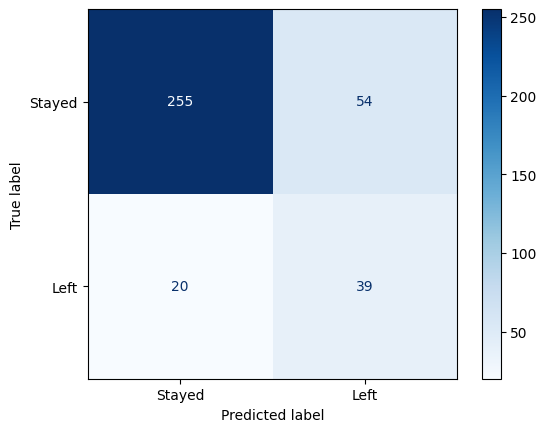

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

hr_numeric_features = [
    "Age",
    "DistanceFromHome",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "MonthlyIncome",
    "NumCompaniesWorked",
    "StockOptionLevel",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
]
hr_categorical_features = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime",
]

# Define features and convert the Yes/No outcome into a binary target.
X_attrition = hr[hr_numeric_features + hr_categorical_features]
y_attrition = hr["Attrition"].map({"No": 0, "Yes": 1})

# Preserve the minority-class proportion in both partitions.
X_hr_train, X_hr_test, y_hr_train, y_hr_test = train_test_split(
    X_attrition,
    y_attrition,
    test_size=0.25,
    stratify=y_attrition,
    random_state=HR_RANDOM_STATE,
)

# Apply suitable transformations to numeric and categorical columns.
hr_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), hr_numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            hr_categorical_features,
        ),
    ]
)
attrition_classifier = make_pipeline(
    hr_preprocessor,
    LogisticRegression(
        class_weight="balanced",
        max_iter=1_000,
        random_state=HR_RANDOM_STATE,
    ),
)

# Fit only on training employees, then estimate risk on unseen employees.
attrition_classifier.fit(X_hr_train, y_hr_train)
attrition_probabilities = attrition_classifier.predict_proba(X_hr_test)[:, 1]
attrition_predictions = attrition_classifier.predict(X_hr_test)

print(f"ROC AUC: {roc_auc_score(y_hr_test, attrition_probabilities):.3f}")
print(classification_report(y_hr_test, attrition_predictions, target_names=["Stayed", "Left"]))

# Show false positives and false negatives at the default probability threshold.
ConfusionMatrixDisplay.from_predictions(
    y_hr_test,
    attrition_predictions,
    display_labels=["Stayed", "Left"],
    cmap="Blues",
)


In [8]:
# Match transformed feature names to fitted logistic-regression coefficients.
classification_feature_names = (
    attrition_classifier.named_steps["columntransformer"].get_feature_names_out()
)
classification_coefficients = attrition_classifier.named_steps[
    "logisticregression"
].coef_[0]

coefficient_table = pd.DataFrame(
    {
        "feature": classification_feature_names,
        "coefficient": classification_coefficients,
    }
)
coefficient_table["association"] = coefficient_table["coefficient"].map(
    lambda value: "higher predicted risk" if value > 0 else "lower predicted risk"
)
strongest_classification_associations = (
    coefficient_table.assign(
        absolute_coefficient=coefficient_table["coefficient"].abs()
    )
    .sort_values("absolute_coefficient", ascending=False)
    .head(12)
)
strongest_classification_associations[
    ["feature", "coefficient", "association"]
].style.format({"coefficient": "{:+.3f}"})


,feature,coefficient,association
35,categorical__JobRole_Research Director,-1.288,lower predicted risk
32,categorical__JobRole_Laboratory Technician,+1.106,higher predicted risk
16,categorical__BusinessTravel_Non-Travel,-1.051,lower predicted risk
38,categorical__JobRole_Sales Representative,+0.968,higher predicted risk
42,categorical__OverTime_No,-0.851,lower predicted risk
30,categorical__JobRole_Healthcare Representative,-0.851,lower predicted risk
17,categorical__BusinessTravel_Travel_Frequently,+0.849,higher predicted risk
43,categorical__OverTime_Yes,+0.728,higher predicted risk
4,numeric__JobLevel,+0.705,higher predicted risk
22,categorical__EducationField_Human Resources,+0.694,higher predicted risk


**Interpretation:** Positive coefficients are associated with higher modelled attrition risk after accounting for the other included variables; negative coefficients are associated with lower modelled risk. They are not proof of causal effects. A probability threshold should be selected according to the consequences of missed cases and false alarms, with appropriate human oversight.


### 3.4 AI Method 2 — Cluster Employees and Investigate Associated Factors

This workflow intentionally excludes `Attrition` from clustering. K-means groups employees using tenure, income, satisfaction, involvement, work–life balance, distance and overtime behaviour. Only after clusters are formed do we compare observed attrition rates.

This design helps describe employee profiles; it does not predict individual outcomes or establish causes.


In [9]:
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

EMPLOYEE_CLUSTER_COUNT = 4
employee_cluster_features = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobSatisfaction",
    "WorkLifeBalance",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsSinceLastPromotion",
]

# Add overtime as a numeric behavioural indicator without using Attrition.
employee_cluster_data = hr[employee_cluster_features].copy()
employee_cluster_data["OverTime"] = hr["OverTime"].map({"No": 0, "Yes": 1})
employee_cluster_input_features = employee_cluster_data.columns.tolist()

# Standardise all inputs, then create four reproducible employee groups.
employee_cluster_model = make_pipeline(
    StandardScaler(),
    KMeans(
        n_clusters=EMPLOYEE_CLUSTER_COUNT,
        n_init=20,
        random_state=HR_RANDOM_STATE,
    ),
)
employee_clusters = employee_cluster_model.fit_predict(employee_cluster_data)

# Attach outcomes only after fitting so they cannot influence cluster formation.
employee_cluster_analysis = employee_cluster_data.copy()
employee_cluster_analysis["cluster"] = employee_clusters
employee_cluster_analysis["attrition_flag"] = hr["Attrition"].map(
    {"No": 0, "Yes": 1}
)
employee_cluster_analysis["JobRole"] = hr["JobRole"]

employee_cluster_profile = employee_cluster_analysis.groupby("cluster").agg(
    employees=("attrition_flag", "size"),
    attrition_rate=("attrition_flag", "mean"),
    mean_age=("Age", "mean"),
    mean_income=("MonthlyIncome", "mean"),
    mean_distance=("DistanceFromHome", "mean"),
    mean_job_satisfaction=("JobSatisfaction", "mean"),
    mean_work_life_balance=("WorkLifeBalance", "mean"),
    mean_years_at_company=("YearsAtCompany", "mean"),
    overtime_rate=("OverTime", "mean"),
)
employee_cluster_profile.style.format(
    {
        "attrition_rate": "{:.1%}",
        "mean_age": "{:.1f}",
        "mean_income": "${:,.0f}",
        "mean_distance": "{:.1f}",
        "mean_job_satisfaction": "{:.2f}",
        "mean_work_life_balance": "{:.2f}",
        "mean_years_at_company": "{:.1f}",
        "overtime_rate": "{:.1%}",
    }
)


,employees,attrition_rate,mean_age,mean_income,mean_distance,mean_job_satisfaction,mean_work_life_balance,mean_years_at_company,overtime_rate
cluster,,,,,,,,,
0,651,10.1%,34.7,"$4,759",5.1,2.71,2.81,5.5,0.0%
1,247,7.7%,47.2,"$14,640",8.5,2.70,2.75,14.8,25.1%
2,345,33.6%,35.4,"$4,948",9.0,2.78,2.73,5.4,100.0%
3,227,15.9%,34.5,"$5,013",22.0,2.74,2.67,5.4,4.0%


Cluster selected for investigation: 2
Observed attrition rate: 33.6%
                        standardised_difference              direction
OverTime                                  +1.59  above overall average
MonthlyIncome                             -0.33  below overall average
TotalWorkingYears                         -0.31  below overall average
YearsAtCompany                            -0.27  below overall average
YearsSinceLastPromotion                   -0.19  below overall average
Age                                       -0.17  below overall average


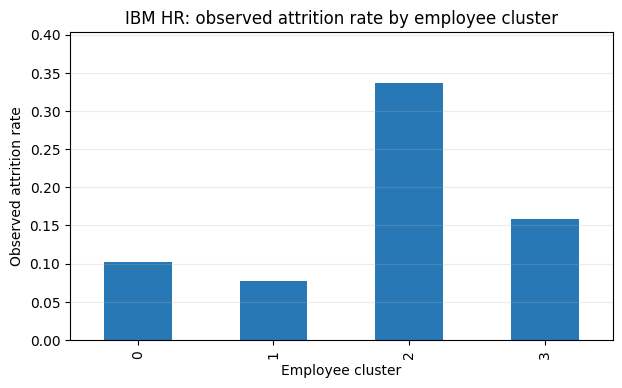

In [10]:
import matplotlib.pyplot as plt

# Identify the cluster with the highest observed attrition rate for investigation.
highest_attrition_cluster = employee_cluster_profile["attrition_rate"].idxmax()
scaled_cluster_centres = employee_cluster_model.named_steps["kmeans"].cluster_centers_
highest_cluster_deviations = pd.Series(
    scaled_cluster_centres[highest_attrition_cluster],
    index=employee_cluster_input_features,
    name="standardised_difference",
).sort_values(key=abs, ascending=False)

# Report which characteristics differ most from the overall standardised average.
possible_associated_factors = highest_cluster_deviations.head(6).to_frame()
possible_associated_factors["direction"] = possible_associated_factors[
    "standardised_difference"
].map(lambda value: "above overall average" if value > 0 else "below overall average")

print(f"Cluster selected for investigation: {highest_attrition_cluster}")
print(
    "Observed attrition rate: "
    f"{employee_cluster_profile.loc[highest_attrition_cluster, 'attrition_rate']:.1%}"
)
print(
    possible_associated_factors.to_string(
        formatters={"standardised_difference": "{:+.2f}".format}
    )
)

# Compare observed attrition rates without implying that the cluster caused attrition.
employee_cluster_profile["attrition_rate"].plot(
    kind="bar",
    figsize=(7, 4),
    color="#2878b5",
)
plt.ylabel("Observed attrition rate")
plt.xlabel("Employee cluster")
plt.title("IBM HR: observed attrition rate by employee cluster")
plt.ylim(0, employee_cluster_profile["attrition_rate"].max() * 1.2)
plt.grid(axis="y", alpha=0.25)
plt.show()


**Interpretation:** The deviation table describes characteristics that distinguish the highest-attrition cluster from the overall dataset. These are possible associated factors for further investigation, not confirmed reasons for leaving. The dataset is fictional, cluster assignments depend on chosen features and `k`, and responsible HR analysis requires consultation, context and fairness review.


### 3.5 Use, Monitor and Improve Attrition Analysis

This teaching dataset is not suitable for operational HR deployment. In a real organisation, deployment would require a documented purpose, lawful data use, privacy controls, employee consultation, human review and a process for contesting or correcting data.

Monitor recall, precision, calibration, data drift and performance across relevant employee groups. Review whether interventions are supportive and whether they improve working conditions. Never use a risk score or cluster as the sole basis for dismissal, promotion, remuneration or access to opportunities.


## 4. AI for Multi-label Text Classification

**Problem:** Can one document be assigned every relevant topic instead of being forced into exactly one class?

Multi-label classification differs from multiclass classification: a document may simultaneously discuss technology, finance and security. This introductory case uses scikit-learn's [`make_multilabel_classification`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_multilabel_classification.html), which generates document-like word-count vectors and multiple topic labels. It is synthetic data for learning the workflow, not real natural-language text.


### 4.1 Generate and Inspect Document-like Data

Each row represents one simulated document. The 60 input features represent word occurrence counts, while five binary target columns indicate whether each topic applies. `allow_unlabeled=False` ensures every document has at least one topic.


In [11]:
import pandas as pd
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split

MULTILABEL_RANDOM_STATE = 42
MULTILABEL_TEST_SIZE = 0.25
topic_names = [
    "technology",
    "finance",
    "health",
    "environment",
    "security",
]

# Generate reproducible bag-of-words counts with several possible topics per document.
X_text_counts, y_topics = make_multilabel_classification(
    n_samples=1_200,
    n_features=60,
    n_classes=len(topic_names),
    n_labels=2,
    length=60,
    allow_unlabeled=False,
    random_state=MULTILABEL_RANDOM_STATE,
)
text_feature_names = [f"term_{index:02d}" for index in range(X_text_counts.shape[1])]
X_text_counts = pd.DataFrame(X_text_counts, columns=text_feature_names)
y_topics = pd.DataFrame(y_topics, columns=topic_names)

# Keep one unseen partition for evaluating all topic predictions together.
X_text_train, X_text_test, y_topic_train, y_topic_test = train_test_split(
    X_text_counts,
    y_topics,
    test_size=MULTILABEL_TEST_SIZE,
    random_state=MULTILABEL_RANDOM_STATE,
)

print(f"Documents: {len(X_text_counts):,}")
print(f"Word-count features: {X_text_counts.shape[1]}")
print(f"Possible topics: {y_topics.shape[1]}")
print(f"Average topics per document: {y_topics.sum(axis=1).mean():.2f}")
y_topics.mean().rename("topic prevalence").to_frame().style.format("{:.1%}")


Documents: 1,200
Word-count features: 60
Possible topics: 5
Average topics per document: 2.18


,topic prevalence
technology,37.5%
finance,59.6%
health,55.0%
environment,47.1%
security,18.4%


### 4.2 Build and Evaluate a One-vs-rest Classifier

`OneVsRestClassifier` fits one logistic regression model per topic. Each model answers a separate yes/no question, allowing several topics to be predicted for one document.

Micro F1 combines decisions across all labels, macro F1 gives each topic equal importance, and Hamming loss is the fraction of individual topic decisions that are incorrect.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, hamming_loss
from sklearn.multiclass import OneVsRestClassifier

# Fit one binary logistic-regression model for each possible topic.
multilabel_text_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1_000,
        random_state=MULTILABEL_RANDOM_STATE,
    )
)
multilabel_text_model.fit(X_text_train, y_topic_train)
topic_predictions = multilabel_text_model.predict(X_text_test)

text_micro_f1 = f1_score(y_topic_test, topic_predictions, average="micro")
text_macro_f1 = f1_score(y_topic_test, topic_predictions, average="macro")
text_hamming_loss = hamming_loss(y_topic_test, topic_predictions)

print(f"Micro F1: {text_micro_f1:.3f}")
print(f"Macro F1: {text_macro_f1:.3f}")
print(f"Hamming loss: {text_hamming_loss:.3f}")
print()
print(classification_report(y_topic_test, topic_predictions, target_names=topic_names))


Micro F1: 0.768
Macro F1: 0.736
Hamming loss: 0.197

              precision    recall  f1-score   support

  technology       0.80      0.65      0.72       115
     finance       0.77      0.77      0.77       171
      health       0.84      0.86      0.85       175
 environment       0.75      0.76      0.76       138
    security       0.81      0.46      0.59        56

   micro avg       0.79      0.74      0.77       655
   macro avg       0.79      0.70      0.74       655
weighted avg       0.79      0.74      0.76       655
 samples avg       0.83      0.84      0.79       655



In [13]:
# Translate binary topic indicators into readable label lists for five documents.
multilabel_examples = []
for row_index in range(5):
    actual_topics = [
        topic_names[index]
        for index, value in enumerate(y_topic_test.iloc[row_index])
        if value == 1
    ]
    predicted_topics = [
        topic_names[index]
        for index, value in enumerate(topic_predictions[row_index])
        if value == 1
    ]
    multilabel_examples.append(
        {
            "actual topics": ", ".join(actual_topics),
            "predicted topics": ", ".join(predicted_topics),
        }
    )

pd.DataFrame(multilabel_examples)


,actual topics,predicted topics
0,"finance, environment",environment
1,"finance, health, environment","finance, environment"
2,technology,"technology, finance, security"
3,"finance, environment","finance, environment"
4,health,"finance, health"


**Interpretation:** This case demonstrates the shape and evaluation of a multi-label workflow, but the generated terms have no human language meaning. A production system would require real, permissioned documents, a defined label taxonomy, human annotation guidance, suitable text features or embeddings, threshold tuning and monitoring for language and topic change.


## 5. AI for Network Intrusion Classification

**Problem:** Can network connection-volume features help distinguish normal HTTP traffic from known intrusion records?

This case is derived from scikit-learn's [`fetch_kddcup99`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_kddcup99.html) `http` subset. KDD Cup 99 was produced from an artificial closed network with injected attacks. It is useful for teaching classification, but its age, synthetic conditions and attack distribution do not represent modern production traffic.


### 5.1 Dataset Description and Preparation

The original downloaded `http` subset contains 58,725 rows in its 10% form. The local classroom file removes duplicate feature/outcome combinations, samples 1,000 unique normal records and retains all 70 unique intrusion records. This reduces duplicate leakage while preserving the realistic difficulty of an imbalanced target.

The three numeric features are `duration`, `src_bytes` and `dst_bytes`. The binary target `intrusion` is `0` for normal and `1` for an intrusion. `original_target` is retained only for inspection and is not used as an input feature.


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split

KDD_DATA_PATH = "sample_data/kddcup99_http_classroom.csv"
KDD_RANDOM_STATE = 42
KDD_TEST_SIZE = 0.25

# Load the deduplicated classroom subset prepared from fetch_kddcup99.
network = pd.read_csv(KDD_DATA_PATH)
network_feature_names = ["duration", "src_bytes", "dst_bytes"]
X_network = network[network_feature_names]
y_intrusion = network["intrusion"]

# Preserve the minority intrusion proportion in the unseen test partition.
X_network_train, X_network_test, y_intrusion_train, y_intrusion_test = train_test_split(
    X_network,
    y_intrusion,
    test_size=KDD_TEST_SIZE,
    stratify=y_intrusion,
    random_state=KDD_RANDOM_STATE,
)

print(f"Classroom rows: {len(network):,}")
print(f"Training rows: {len(X_network_train):,}")
print(f"Test rows: {len(X_network_test):,}")
network["intrusion"].value_counts().sort_index().rename("rows").to_frame()


Classroom rows: 1,070
Training rows: 802
Test rows: 268


,rows
intrusion,
0,1000
1,70


### 5.2 Build and Evaluate the Intrusion Classifier

The pipeline standardises the three numeric features and fits logistic regression. `class_weight="balanced"` gives the smaller intrusion class more influence during training.

Recall is important because it measures detected intrusions, while precision shows how many alerts correspond to intrusion records. ROC AUC evaluates ranking across probability thresholds.


ROC AUC: 0.991
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       250
   Intrusion       0.75      1.00      0.86        18

    accuracy                           0.98       268
   macro avg       0.88      0.99      0.92       268
weighted avg       0.98      0.98      0.98       268



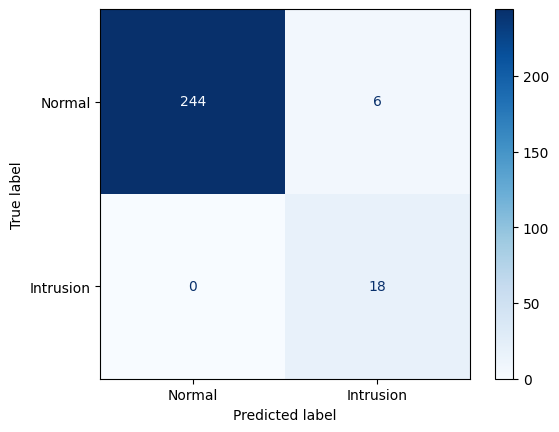

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Standardise connection features and compensate for the imbalanced training target.
intrusion_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        max_iter=1_000,
        random_state=KDD_RANDOM_STATE,
    ),
)
intrusion_model.fit(X_network_train, y_intrusion_train)
intrusion_predictions = intrusion_model.predict(X_network_test)
intrusion_probabilities = intrusion_model.predict_proba(X_network_test)[:, 1]

print(f"ROC AUC: {roc_auc_score(y_intrusion_test, intrusion_probabilities):.3f}")
print(
    classification_report(
        y_intrusion_test,
        intrusion_predictions,
        target_names=["Normal", "Intrusion"],
    )
)

# Display missed intrusions and false alerts at the default probability threshold.
ConfusionMatrixDisplay.from_predictions(
    y_intrusion_test,
    intrusion_predictions,
    display_labels=["Normal", "Intrusion"],
    cmap="Blues",
)


**Interpretation:** Strong test performance on this classroom subset would show that these historical attack records are separable using three connection-volume features. It would not demonstrate readiness for real intrusion detection. Operational validation requires current traffic, time-based testing, evolving attack types, latency assessment, false-alert review, security controls and continuous monitoring for adversarial change.
